# Fallos en Placas de Acero (Steel Plates Faults)


- Este dataset está disponible en Kaggle (originalmente donado por Semeion Research Center).

- No contiene imágenes crudas, sino características extraídas mediante visión artificial de imágenes de placas de acero.

- **Nombre:** Steel Plates Faults.

- **Contexto:** Ingeniería Metalúrgica / Control de Calidad.

- **Objetivo:** Clasificar el tipo de defecto superficial en una placa de acero inoxidable basándose en características geométricas y radiométricas.

### Las Variables Predictoras ($X$) - 27 Características

#### Geometría y Forma:
- Pixels_Areas, Perimeter: Tamaño del defecto.
- X_Perimeter, Y_Perimeter: Proyecciones del perímetro.
- Shape_Index, Square_Index: ¿El defecto es redondo? ¿Es cuadrado?
- Steel_Plate_Thickness: Grosor de la placa (dato de proceso).
  
#### Posición (Ubicación espacial):
- X_Minimum, X_Maximum: Dónde está el defecto respecto al ancho de la banda transportadora.
- Y_Minimum, Y_Maximum: Posición longitudinal.

#### Luminosidad y Textura (Radiometría):
- Sum_of_Luminosity, Minimum_of_Luminosity, Maximum_of_Luminosity: Intensidad de luz reflejada. Ayuda a distinguir, por ejemplo, una mancha de aceite (oscura) de un rasguño (brillante).

#### Bordes y Contornos:
- Edges_Index, Empty_Index: Complejidad del borde del defecto.

### La Variable Objetivo ($y$) - 7 Tipos de Fallos

Las clases que vamos a predecir son fallos típicos en laminación:
- **Pastry:** Defectos por material pegado o residuos aplastados.
- **Z_Scratch:** Arañazos en zigzag.K_Scatch:
- **Arañazos** longitudinales específicos.
- **Stains:** Manchas (líquidos, óxido).
- **Dirtiness:** Suciedad superficial.
- **Bumps:** Protuberancias o abolladuras.
- **Other_Faults:** Cajón de sastre para otros defectos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


In [2]:
#from google.colab import files
#files.upload()

#data = pd.read_csv('SteelPlatesFaults.csv')

In [3]:
# Carga del dataset
df = pd.read_csv('data/SteelPlatesFaults.csv')
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Pastry,Z_Scratch,K_Scatch,Stains,Dirtiness,Bumps,Other_Faults
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.8182,-0.2913,0.5822,1,0,0,0,0,0,0
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.7931,-0.1756,0.2984,1,0,0,0,0,0,0
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.6667,-0.1228,0.2150,1,0,0,0,0,0,0
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.8444,-0.1568,0.5212,1,0,0,0,0,0,0
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.9338,-0.1992,1.0000,1,0,0,0,0,0,0


In [4]:
# PREPARACIÓN DEL TARGET (y) y de data (X)

# Lista de las 7 columnas que representan los tipos de fallos
target_cols = [
    'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 
    'Dirtiness', 'Bumps', 'Other_Faults'
]
# Usamos .idxmax(): Mira las 7 columnas y devuelve el NOMBRE de la columna que tiene el valor más alto (1).
# Convierte [1, 0, 0, ...] -> "Pastry"
y_nombres = df[target_cols].idxmax(axis=1)
# Convertimos los nombres a números (0 a 6)
encoder = LabelEncoder()
y = encoder.fit_transform(y_nombres)
X = df.drop(columns=target_cols)

array([4, 4, 4, ..., 3, 3, 3])

In [5]:
# DIVISIÓN TRAIN / TEST 

# Separamos el 20% para test. Usamos stratify=y para mantener la proporción de fallos.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de y_train:", y_train.shape)
y

Dimensiones de X_train: (1552, 27)
Dimensiones de y_train: (1552,)


array([4, 4, 4, ..., 3, 3, 3])

### ESCALADO

In [6]:
# Mostramos estadísticas de solo 3 columnas muy diferentes para ver el problema de escala
cols_ejemplo = ['Pixels_Areas', 'Steel_Plate_Thickness', 'Square_Index']
print(X_train[cols_ejemplo].describe().loc[['min', 'max', 'mean', 'std']])

      Pixels_Areas  Steel_Plate_Thickness  Square_Index
min       2.000000              40.000000      0.009000
max   37334.000000             300.000000      1.000000
mean   1870.083119              77.880799      0.571894
std    4007.855796              54.587976      0.269691


In [7]:
scaler = StandardScaler()

# IMPORTANTE: 
# 1. Hacemos .fit() SOLO con X_train (aprendemos la media/std del entrenamiento).
# 2. Transformamos X_train y X_test con esa media/std.
# Nunca hagas .fit() con todo el dataset o tendrás "Data Leakage" (fuga de información).

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertimos a DataFrame solo para visualización
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("\n=== 3. VERIFICACIÓN DEL ESCALADO ===")
print("Medias después de escalar (deben ser aprox 0):\n", X_train_scaled_df[cols_ejemplo].mean())
print("Std Dev después de escalar (deben ser aprox 1):\n", X_train_scaled_df[cols_ejemplo].std())


=== 3. VERIFICACIÓN DEL ESCALADO ===
Medias después de escalar (deben ser aprox 0):
 Pixels_Areas             0.000000e+00
Steel_Plate_Thickness    8.298059e-17
Square_Index            -2.609596e-16
dtype: float64
Std Dev después de escalar (deben ser aprox 1):
 Pixels_Areas             1.000322
Steel_Plate_Thickness    1.000322
Square_Index             1.000322
dtype: float64


### ANÁLISIS DE LAS VARIABLES PREDICTORAS

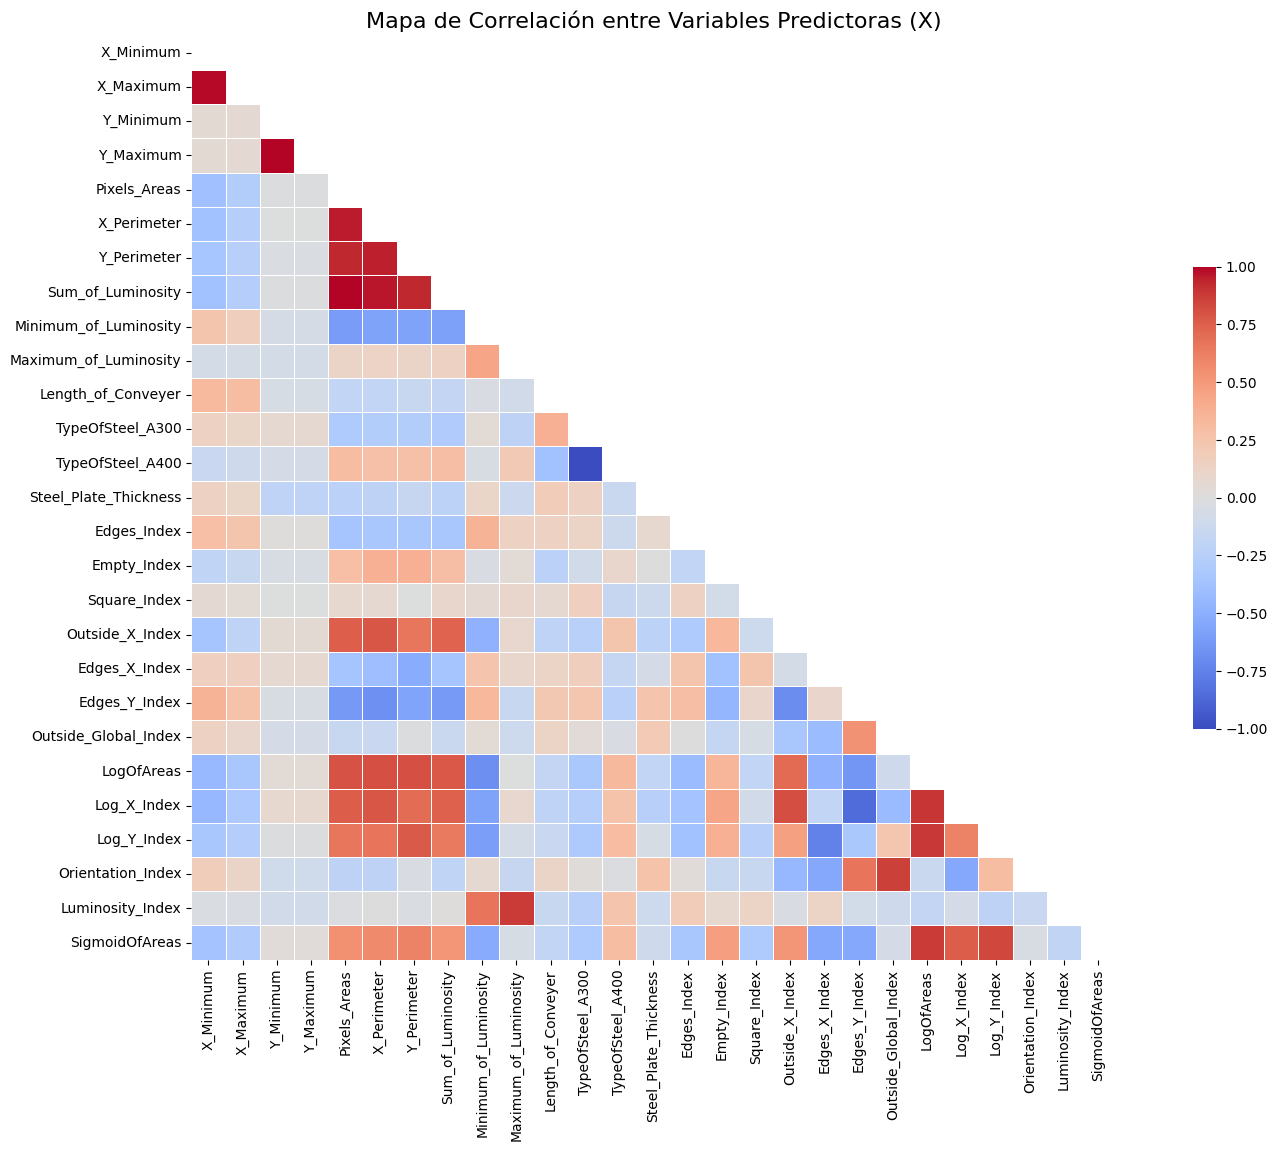

In [8]:
# CORRELACIÓN

corr_matrix = X_train.corr()

# Creamos una máscara para ocultar la mitad superior (es simétrica y redundante)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(20, 12))

# Mapa de calor
sns.heatmap(corr_matrix, 
            mask=mask, 
            cmap='coolwarm',  # Rojo = Corr Positiva, Azul = Corr Negativa
            vmax=1, vmin=-1, 
            center=0,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .5},
            annot=False) # Pon annot=True si quieres ver los números (se verá muy denso)

plt.title('Mapa de Correlación entre Variables Predictoras (X)', fontsize=16)
plt.show()

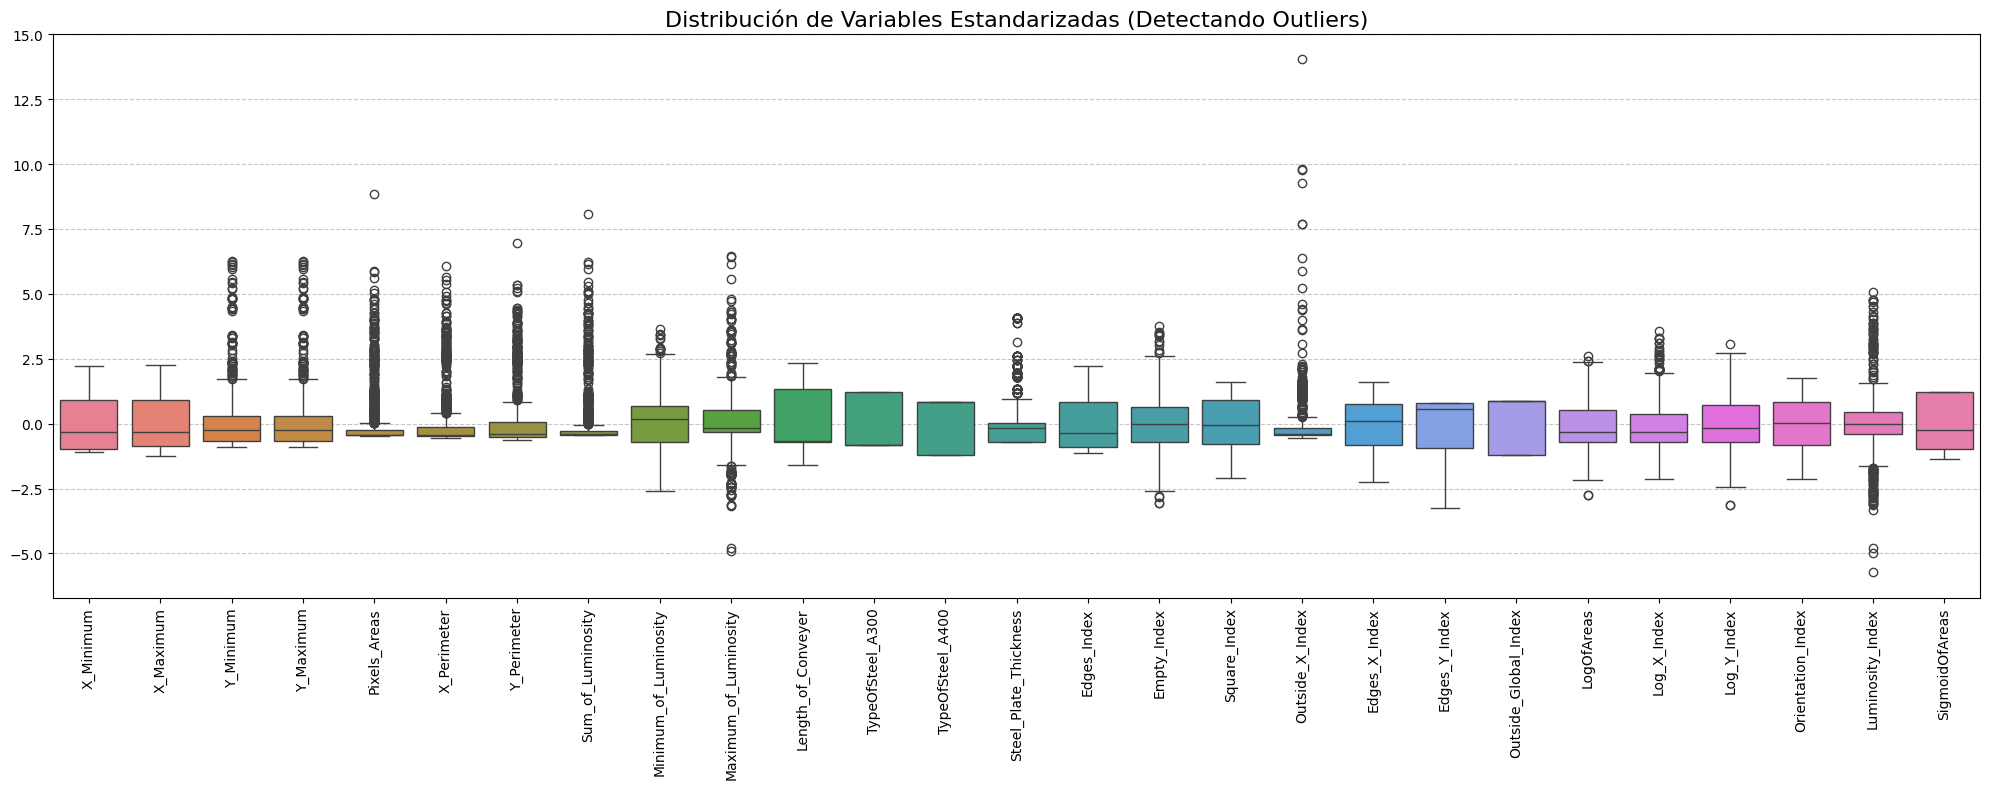

In [9]:
# Boxplots (Distribución y Outliers)

X_train_scaled_df = pd.DataFrame(scaler.transform(X_train), columns=X.columns)

plt.figure(figsize=(20, 8))

# Boxplot de todas las variables
sns.boxplot(data=X_train_scaled_df)

plt.xticks(rotation=90) # Rotamos nombres para leerlos
plt.title('Distribución de Variables Estandarizadas (Detectando Outliers)', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### ANÁLISIS DE LA VARIABLE OBJETIVO

In [10]:
unique, counts = np.unique(y_train, return_counts=True)
total_samples = len(y_train)

print(f"{'Clase (Fallo)':<20} | {'Muestras':<10} | {'Proporción'}")
print("-" * 45)
for i, count in zip(unique, counts):
    # Recuperamos el nombre original usando el encoder que definimos antes
    nombre_clase = encoder.inverse_transform([i])[0]
    print(f"{nombre_clase:<20} | {count:<10} | {count/total_samples:.1%}")

Clase (Fallo)        | Muestras   | Proporción
---------------------------------------------
Bumps                | 321        | 20.7%
Dirtiness            | 44         | 2.8%
K_Scatch             | 313        | 20.2%
Other_Faults         | 538        | 34.7%
Pastry               | 126        | 8.1%
Stains               | 58         | 3.7%
Z_Scratch            | 152        | 9.8%


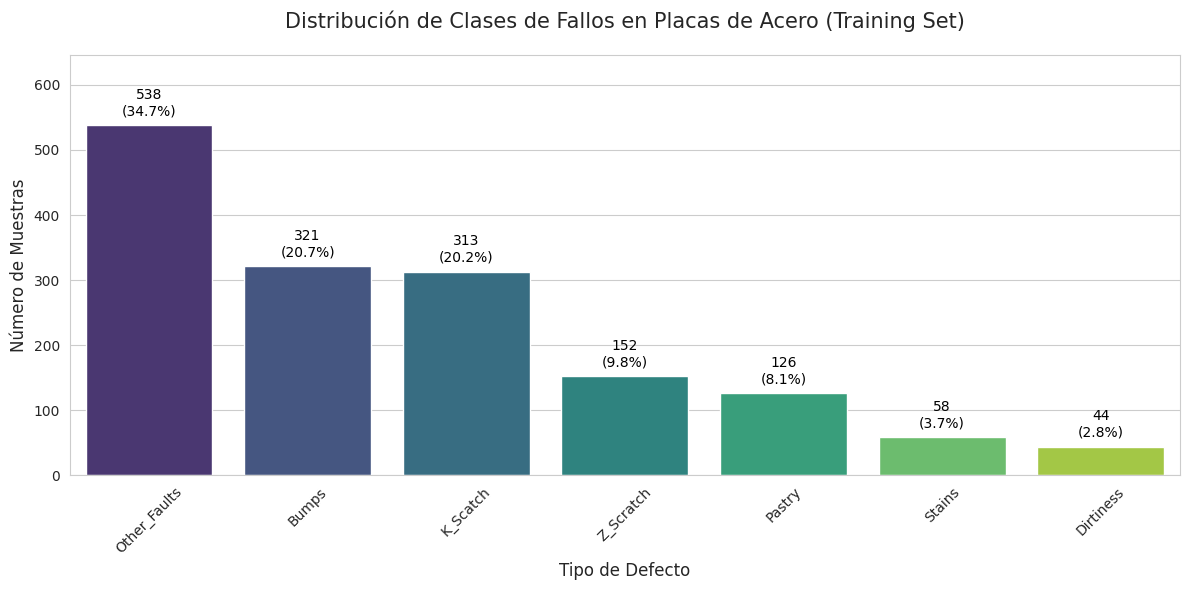

In [11]:
# Contamos las clases en y_train
unique, counts = np.unique(y_train, return_counts=True)

# Recuperamos los nombres reales usando el encoder (ej: 0 -> 'Pastry')
nombres_clases = encoder.inverse_transform(unique)

# Creamos un DataFrame temporal. Esto hace que Seaborn funcione mejor y podamos ordenar.
df_plot = pd.DataFrame({
    'Clase': nombres_clases,
    'Muestras': counts
})

# Ordenamos de mayor a menor frecuencia (estilo Pareto) para mejorar la lectura
df_plot = df_plot.sort_values('Muestras', ascending=False)
total_samples = len(y_train)

# GENERACIÓN DEL GRÁFICO

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")  # Pone una rejilla suave de fondo

# Creamos el gráfico de barras
ax = sns.barplot(data=df_plot, x='Clase', y='Muestras', palette='viridis', hue='Clase', legend=False)

# AÑADIR ETIQUETAS DE TEXTO (Conteos y %)

# Iteramos sobre cada barra (patch) del gráfico
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Solo etiquetamos si hay datos
        pct = (height / total_samples) * 100
        # Escribimos el texto: "Cantidad \n (Porcentaje%)"
        ax.annotate(f'{int(height)}\n({pct:.1f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, color='black',
                    xytext=(0, 5),         # Desplazamiento vertical de 5 puntos
                    textcoords='offset points')

plt.title('Distribución de Clases de Fallos en Placas de Acero (Training Set)', fontsize=15, pad=20)
plt.xlabel('Tipo de Defecto', fontsize=12)
plt.ylabel('Número de Muestras', fontsize=12)
plt.xticks(rotation=45)  # Rotamos los nombres si son largos
plt.ylim(0, df_plot['Muestras'].max() * 1.2) # Damos un 20% de espacio arriba para que quepan las etiquetas

plt.tight_layout()
plt.show()

### StratifiedKFold

In [14]:
# Usamos StratifiedKFold para mantener la proporción de fallos en cada validación
cv_clasificacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## REGRESIÓN LOGÍSTICA (Normal vs Polinómica)

In [15]:
# Paso A: Definir el Pipeline (Transformación -> Modelo)
pipe_logistica = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)), # El grado lo definimos en params
    ('log_reg', LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42))
])

# Paso B: Definir los hiperparámetros a probar
params_logistica = {
    # Probamos grado 1 (Lineal) vs grado 2 - 3 (Polinómica)
    'poly__degree': [1, 2, 3], 
    
    # Pequeño (0.1) = Mucha regularización (evita overfitting).
    # Grande (10) = Poca regularización.
    'log_reg__C': [0.1, 1.0, 10.0],
    
    # Probamos si balancear los pesos ayuda con las clases minoritarias
    'log_reg__class_weight': [None, 'balanced']
}

grid_logistica = GridSearchCV(
    estimator=pipe_logistica,
    param_grid=params_logistica,
    cv=cv_clasificacion,
    scoring='f1_macro', # Clave para datos desbalanceados
    n_jobs=-1,
    verbose=1
)

## SVM (Kernels: Lineal, RBF, Poly)

In [16]:
model_svm = SVC(random_state=42)

params_svm = {
    # Probamos diferentes kernel
    'kernel': ['linear', 'rbf', 'poly'],
    
    # Regularización
    'C': [0.1, 1.0, 10.0],
    
    # Gamma: "Radio de influencia" de cada punto (Solo afecta a RBF y Poly)
    # 'scale' es automático, 'auto' es 1/n_features. A veces uno funciona mejor que otro.
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    estimator=model_svm,
    param_grid=params_svm,
    cv=cv_clasificacion,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

In [17]:
print("=== 1. Buscando el mejor modelo de Regresión Logística (Lineal vs Poly) ===")

grid_logistica.fit(X_train_scaled, y_train)

print(f"\nMejor Logística: {grid_logistica.best_params_}")
print(f"Mejor F1-Macro: {grid_logistica.best_score_:.4f}")



=== 1. Buscando el mejor modelo de Regresión Logística (Lineal vs Poly) ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejor Logística: {'log_reg__C': 0.1, 'log_reg__class_weight': None, 'poly__degree': 2}
Mejor F1-Macro: 0.7858


In [18]:
print("\n=== 2. Buscando el mejor modelo SVM (Lineal vs RBF vs Poly) ===")
grid_svm.fit(X_train_scaled, y_train)

print(f"\nMejor SVM: {grid_svm.best_params_}")
print(f"Mejor F1-Macro: {grid_svm.best_score_:.4f}")


=== 2. Buscando el mejor modelo SVM (Lineal vs RBF vs Poly) ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejor SVM: {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor F1-Macro: 0.7750


### INTERPRETACIÓN DE RESULTADOS

El modelo clásico con polinomio grado 2 ha ganado a SVM
- poly__degree: 2: El modelo ha detectdo que las interacciones entre variables son clave. En ingeniería esto tiene todo el sentido: un defecto no se define solo por el Ancho o el Largo, sino por el Area ($Ancho \times Largo$). Al elevar al cuadrado, el modelo "descubrió" fórmulas físicas.
- log_reg__C: 0.1: Eligió una regularización fuerte (C bajo). Como al crear polinomios se generaron cientos de variables nuevas, el modelo tuvo que ser "estricto" y apagar muchas de ellas para no confundirse con el ruido.
- Conclusión: La geometría de los fallos en el acero se explica mejor multiplicando variables (polinomios) que calculando distancias puras.

SVM se quedó muy cerca, pero no superó a la logística.

- kernel: 'rbf': Confirmamos que el problema NO es lineal. El kernel lineal tiene peores resultados. El RBF crea "burbujas" o contornos curvos alrededor de los grupos de fallos.

- C: 10.0: A diferencia de la logística, la SVM necesitó una regularización débil (C alto). Esto significa que la SVM intentó ajustarse mucho a los datos de entrenamiento, siendo muy estricta con los errores. Es posible que esto le restara un poco de capacidad de generalización frente a la logística.

### MATRIZ DE CONFUSIÓN

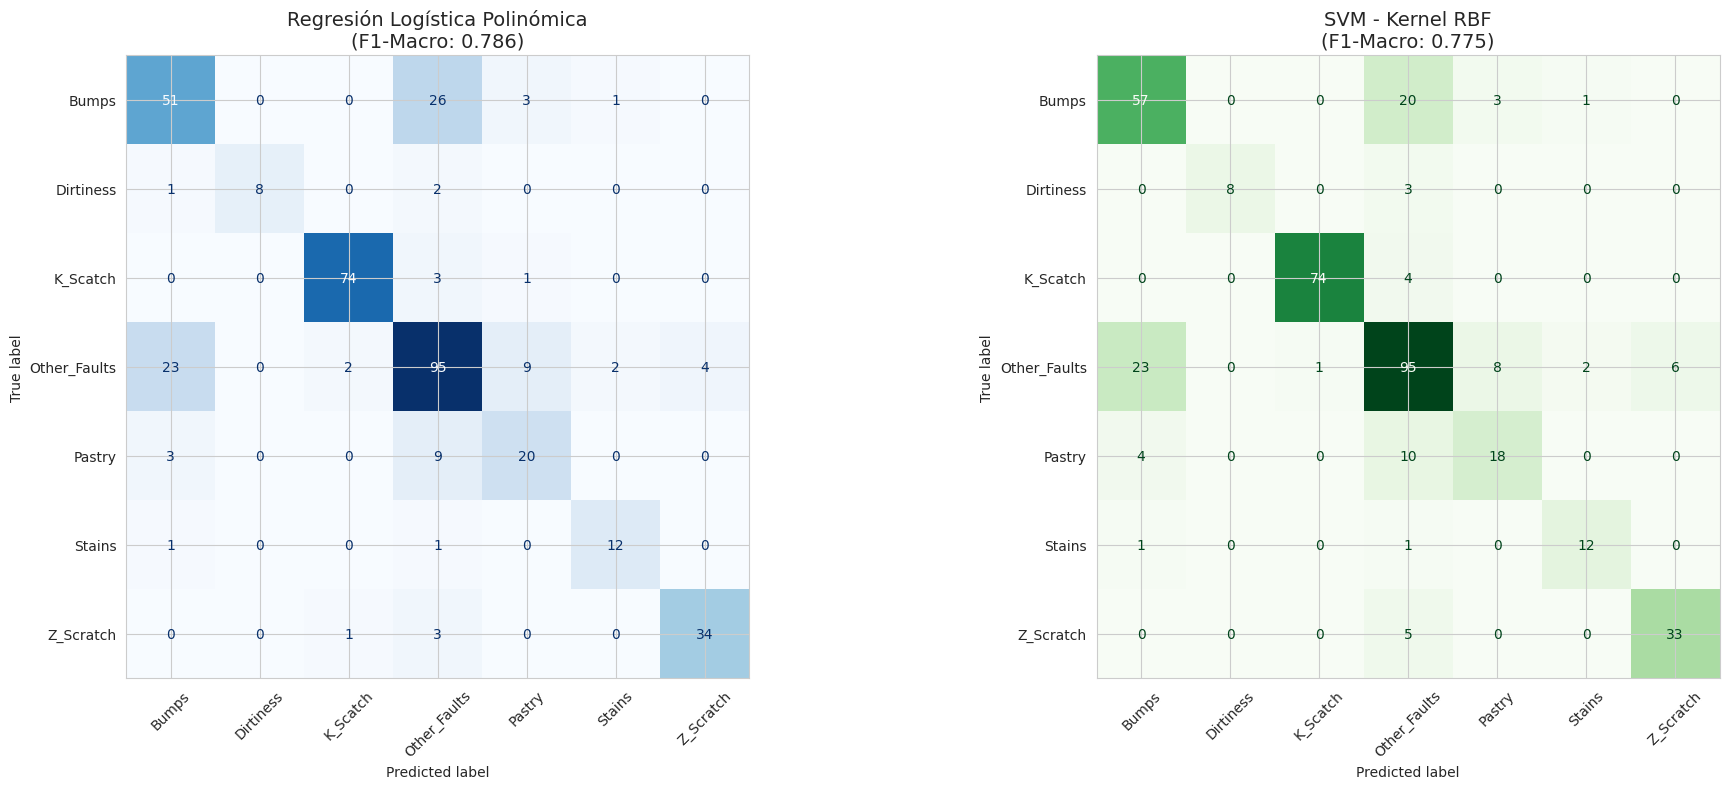

In [20]:
# 1. Recuperamos los mejores modelos ya entrenados del GridSearch
best_log_reg = grid_logistica.best_estimator_
best_svm = grid_svm.best_estimator_

# 2. Hacemos predicciones sobre el Test Set (que no han visto nunca)
y_pred_log = best_log_reg.predict(X_test_scaled)
y_pred_svm = best_svm.predict(X_test_scaled)

# 3. Recuperamos los nombres de las clases para que el gráfico sea legible
class_names = encoder.inverse_transform(sorted(list(set(y))))

# 4. Configuración del gráfico (Doble panel)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Gráfico A: Regresión Logística Polinómica ---
cm_log = ConfusionMatrixDisplay.from_estimator(
    best_log_reg, 
    X_test_scaled, 
    y_test, 
    display_labels=class_names,
    cmap='Blues',
    xticks_rotation=45,
    ax=axes[0],
    colorbar=False
)
axes[0].set_title(f'Regresión Logística Polinómica\n(F1-Macro: {grid_logistica.best_score_:.3f})', fontsize=14)

# --- Gráfico B: SVM (Kernel RBF) ---
cm_svm = ConfusionMatrixDisplay.from_estimator(
    best_svm, 
    X_test_scaled, 
    y_test, 
    display_labels=class_names,
    cmap='Greens',
    xticks_rotation=45,
    ax=axes[1],
    colorbar=False
)
axes[1].set_title(f'SVM - Kernel RBF\n(F1-Macro: {grid_svm.best_score_:.3f})', fontsize=14)

plt.tight_layout()
plt.show()